# MOwNiT
## Laboratorium
### Całkowanie

In [16]:
# Dependencies
using Pkg
Pkg.precompile()
Pkg.update()
Pkg.add("QuadGK")
Pkg.add("Plots")
using QuadGK
using Polynomials
using Plots
using Printf

    Updating registry at `~/.julia/registries/General.toml`
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


Kwadratury Gaussa bazują na tzw. odciętych punktów Gaussa $x_{i}$ oraz współczynnikach $a_{i}$


In [2]:
# funkcja obliczająca odcięte punktów Gaussa oraz ich współczynniki
(xp, a) = gauss(Float64,7);

In [3]:
xp

7-element Vector{Float64}:
 -0.9491079123427585
 -0.7415311855993945
 -0.4058451513773972
  0.0
  0.4058451513773972
  0.7415311855993945
  0.9491079123427585

In [4]:
a

7-element Vector{Float64}:
 0.12948496616886981
 0.2797053914892767
 0.38183005050511887
 0.41795918367346907
 0.38183005050511887
 0.2797053914892767
 0.12948496616886981

Podstawowe użycie w/w danych: 
aby policzyć $\int_{-1}^{1} f dx$  używamy odciętych punktów wraz z wagami wg wzoru 
$\sum_{i=1}^{n}{a_{i}f(x_{i})}$


In [5]:
f(x)=x^2
sum(a .* f.(xp)) 

0.6666666666666669

### Zadanie 1 (1p)
- Korzytając z pakietu <a href="https://github.com/JuliaMath/Polynomials.jl">Polynomials</a> zaimplementuj wielomiany Legendre'a zdefiniowane w taki sposób:

$P_{0}(x)=1$

$P_{1}(x)=x$

$P_{k+1}(x)=\frac{2k+1}{k+1} x P_{k}(x)-\frac{k}{k+1}P_{k-1}(x)$

- narysuj ich wykresy w przedziale (-1,1). 
- sprawdź(np. za pomocą fukcji <i>roots</i> z pakietu Polynomials), że ich zera  sa odciętymi punktów Gaussa. Test wykonaj dla wielomianow od 2 do 4 stopnia
- podaj związek tego faktu z podstawowym twierdzeniem kwadratur Gaussa (z wykładu)

In [132]:
function legendrePoly(n::Int)
    p_k_minus_1 = Polynomial([1.0])
    p_k = Polynomial([0.0, 1.0])
    
    if n == 0 return p_k_minus_1 end
    if n == 1 return p_k end
    
    x = Polynomial([0.0, 1.0])

    local p_k_plus_1
    for k in 1:(n-1)
        p_k_plus_1 = ((2k + 1) / (k + 1)) * x * p_k - (k / (k + 1)) * p_k_minus_1
        
        p_k_minus_1 = p_k
        p_k = p_k_plus_1
    end
    
    return p_k_plus_1
end

legendrePoly (generic function with 1 method)

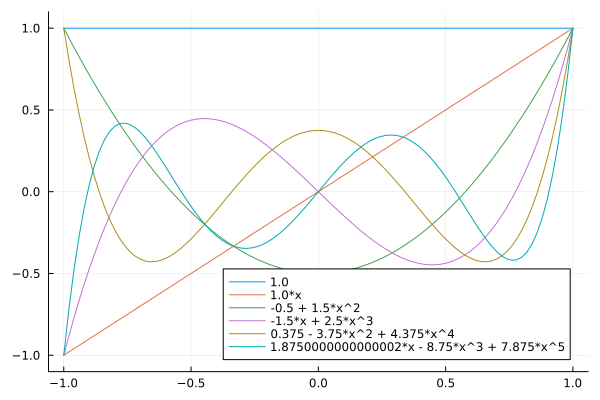

In [33]:
functions = Vector{Function}()
p0 = legendrePoly(0)
p1 = legendrePoly(1)
p2 = legendrePoly(2)
p3 = legendrePoly(3)
p4 = legendrePoly(4)
p5 = legendrePoly(5)
xs = -1:1
plot(p0,extrema(xs)...)
plot!(p1,extrema(xs)...)
plot!(p2,extrema(xs)...)
plot!(p3,extrema(xs)...)
plot!(p4,extrema(xs)...)
plot!(p5,
    extrema(xs)...,
    ylim = (-1.1,1.1))
     


In [36]:
println("Degree 2")
println(sort(roots(p2)))
xp, a = gauss(Float64, 2)
println(xp)
println("---------")
println("Degree 3")
println(sort(roots(p3)))
xp, a = gauss(Float64, 3)
println(xp)
println("---------")
println("Degree 4")
println(sort(roots(p4)))
xp, a = gauss(Float64, 4)
println(xp)
println("---------")

# Odcięte (węzły) xi n-punktowej kwadratury Gaussa z funkcja ważaca w(x) w [a, b] sa zerami wielomianu ortogonalnego phi_n(x)
# dla tego samego przedziału i tej samej funkcji ważacej.

Degree 2
[-0.5773502691896258, 0.5773502691896256]
[-0.5773502691896258, 0.5773502691896258]
---------
Degree 3
[-0.7745966692414834, 0.0, 0.7745966692414835]
[-0.7745966692414834, 0.0, 0.7745966692414834]
---------
Degree 4
[-0.861136311594053, -0.33998104358485637, 0.3399810435848563, 0.8611363115940521]
[-0.8611363115940526, -0.3399810435848563, 0.3399810435848563, 0.8611363115940526]
---------


### Zadanie 2 (1p)
- Napisz funkcję, która dla podanej liczby punktów Gaussa $k$ oraz funkcji $f$  policzy $\int_{-1}^{1} f dx$
metodą używającą funkcji:
```julia
gauss(k)
```
oraz sumy 
```julia
sum(a .* f.(xp)) 
```
- przetestuj dla wielomianów coraz większych stopni (uwaga: dobrać takie współczynniki wielomianów, aby całka nie zerowała się w przedziale [-1.1])
- sprawdz kiedy przestaje być dokładna, 
- podaj związek z twierdzeniem o  stopniu dokładności kwadratury Gaussa 

In [55]:
function gaussIntegral(k,f)
    (xp, a) = gauss(k)
    return sum(a.*f.(xp))
end

gaussIntegral (generic function with 1 method)

In [60]:
test = [[i == j ? j : (i == 1 ? 1 : 0) for i in 1:j] for j in 1:10]
# 1 + nx^n
println(test)

for i in 1:10
    poly = Polynomial(test[i])
    expected_val = i == 1 ? 2 : 2 + 1^i - (-1)^i
    println("Polynomial level $i: $(gaussIntegral(3, poly)) Expected: $expected_val")
end


# Funkcja przestaje być dokładna przy stopniu wielomianu równym 7. Wynika to z twierdzenia o 
# stopniu dokładności kwadratur Gaussa - jest ona dokładna dla wielomianu o stopniu równym maksymalnie 2n-1
# zatem dla kwadratury równej 3 dokładność kończy się na wielomianie stopnia 5.

[[1], [1, 2], [1, 0, 3], [1, 0, 0, 4], [1, 0, 0, 0, 5], [1, 0, 0, 0, 0, 6], [1, 0, 0, 0, 0, 0, 7], [1, 0, 0, 0, 0, 0, 0, 8], [1, 0, 0, 0, 0, 0, 0, 0, 9], [1, 0, 0, 0, 0, 0, 0, 0, 0, 10]]
Polynomial level 1: 1.9999999999999998 Expected: 2
Polynomial level 2: 1.9999999999999996 Expected: 2
Polynomial level 3: 4.0 Expected: 4
Polynomial level 4: 1.9999999999999998 Expected: 2
Polynomial level 5: 4.0 Expected: 4
Polynomial level 6: 1.9999999999999998 Expected: 2
Polynomial level 7: 3.6800000000000006 Expected: 4
Polynomial level 8: 1.9999999999999998 Expected: 2
Polynomial level 9: 3.2960000000000003 Expected: 4
Polynomial level 10: 1.9999999999999998 Expected: 2


### Zadanie 3 (1p)
  
Skorzystaj z rozwiązania zadania 2 do napisania funkcji 
liczącej  całki w dowolnym przedziale $\int_{a}^{b} f(x) dx$ 

dokonując normalizacji  do $\int_{-1}^{1} F(z) dz$ 

podstawiając:

$x=\frac{b+a}{2}+ \frac{b-a}{2} z $ oraz 

$dx =\frac{b-a}{2} dz $

Przetestuj działanie na kilku przykładach i sprawdź z wynikami otrzymanymi analitycznie.


In [62]:
function overallIntegral(k, f, a, b)
    (z, w) = gauss(k)
    mid = (b + a) / 2
    half = (b - a) / 2
    x = half .* z .+ mid
    value = half * sum(w .* f.(x))
    return value
end

overallIntegral (generic function with 1 method)

In [69]:
test1 = Polynomial([0, 2, 1])

for i in 1:5
    val = overallIntegral(i, test1, 0, 3)
    println("Quadrature: $i | Expected: 18.0| Got: $val")
end

# Pierwsza wartość jest niedokładana przez własność kwadratur gausa, przy wielomianie 1 stopnia dokladnosc to 1 (a polynomial jest stopnia 2)

Quadrature: 1 | Expected: 18.0| Got: 15.75
Quadrature: 2 | Expected: 18.0| Got: 18.0
Quadrature: 3 | Expected: 18.0| Got: 18.0
Quadrature: 4 | Expected: 18.0| Got: 18.0
Quadrature: 5 | Expected: 18.0| Got: 17.999999999999996


In [72]:
test2 = exp

for i in 1:5
    println("Quadrade: $i | Expected: 1.0 Got: $(overallIntegral(i,exp,0,log(2)))")
end

Quadrade: 1 | Expected: 1.0 Got: 0.9802581434685471
Quadrade: 2 | Expected: 1.0 Got: 0.9999473706763962
Quadrade: 3 | Expected: 1.0 Got: 0.9999999458752024
Quadrade: 4 | Expected: 1.0 Got: 0.9999999999705373
Quadrade: 5 | Expected: 1.0 Got: 0.9999999999999899


In [73]:
test3 = cos

for i in 1:5
    println("Quadrade: $i | Expected: 1,6829 Got: $(overallIntegral(i,cos,-1,1))")
end

Quadrade: 1 | Expected: 1,6829 Got: 2.0
Quadrade: 2 | Expected: 1,6829 Got: 1.6758236553899857
Quadrade: 3 | Expected: 1,6829 Got: 1.6830035477269165
Quadrade: 4 | Expected: 1,6829 Got: 1.6829416886959732
Quadrade: 5 | Expected: 1,6829 Got: 1.6829419704071917


### Zadanie 4 (1p)
Głowną funkcją pakietu QuadGK jest adaptacyjna funkcja <a href="https://juliamath.github.io/QuadGK.jl/stable/#QuadGK.quadgk"> guadgk</a> używająca całkowania  Gauss-Kronroda

- użyj tej funkcji do policzenia  całki dla przykładowego wielomianu.
- funkcja ta ma możliwość liczenia również całek do nieskończoności.


 Policz całkę od minus do plus nieskonczonosci 
 standardowego rozkładu normalnego Gaussa
$ \frac{1}{\sqrt{2\pi}}exp(\frac{-x^2}{2})$

In [130]:
# Przykladowy wielomian
samplePoly = Polynomial([1,5,2,3])
println("Function: $(samplePoly) Interval: [-5,5]")
println("Expected: 176,67 Got: $(quadgk(samplePoly,-5,5)[1])")

Function: 1 + 5*x + 2*x^2 + 3*x^3 Interval: [-5,5]
Expected: 176,67 Got: 176.66666666666634


In [131]:
# Rozklad normalny Gaussa
gaussFunction(x) = 1/sqrt(2*pi)*exp((-x^2)/2)
println("Function: $(gaussFunction) Interval: [-inf,inf]")
println("Expected: 1 Got: $(quadgk(gaussFunction,-Inf,Inf)[1])")

Function: gaussFunction Interval: [-inf,inf]
Expected: 1 Got: 1.0000000000032583


### Zadanie 5 (3p)
Napisz własne funkcje całkujące -  w wybranym przedziale (a,b) - złożonymi metodami prostokątów, trapezów oraz Simpsona. Dla stałego przedziału zwiększaj liczbę użytych punktów (n). Narysuj wykresy funkcji błędu  w stosunku do wyniku otrzymanego analitycznie, 
w zależnosci od $h=\frac{b-a}{n}$:
1. wykładniczej
2. trygonometrycznej (np. sin (x) w przedziale $[0,2\pi]$)


In [126]:
using Plots.PlotMeasures

# przyblizanie prostokatami
function rectangleIntegral(f, a, b, n)
    h = (b-a)/n
    value = 0
    for i in 1:1:n
        # mid = a + (i - 0.5)*h
        value += f(a+(i-0.5)*h)
    end
    return value * h
end

# przyblizanie trapezami
function trapezoidIntegral(f, a, b, n)
    h = (b-a)/n
    value = 0
    for j in 1:1:n-1
        value += f(a + j * h)
    end
    value = (value + (f(a)+f(b))/2)*h 
    return value
end

# Przy uzyciu wielomianu 2 stopnia
function simpsonIntegral(f, a, b, n)
    value  = 0
    st = 0
    h = (b-a)/n
    for i in 1:n
        x = a + i * h
        st += f(x - h / 2)
        if i < n 
            value += f(x)
        end
    end
    value = h / 6 * (f(a) + f(b) + 2 * value + 4 * st)
    return value
end

# Funkcja rysująca wykresy błędów
function plotErrors(f, a, b, exact, label)
    ns = 1:10
    hs = (b - a) ./ ns
    errors_rect = Float64[]
    errors_trap = Float64[]
    errors_simp = Float64[]

    for n in ns
        err_r = abs(rectangleIntegral(f, a, b, n) - exact)
        err_t = abs(trapezoidIntegral(f, a, b, n) - exact)
        err_s = abs(simpsonIntegral(f, a, b, n) - exact)
        
        push!(errors_rect, max(err_r, 1e-16))
        push!(errors_trap, max(err_t, 1e-16))
        push!(errors_simp, max(err_s, 1e-16))
    end

    plot(
        hs,
        [errors_rect errors_trap errors_simp],
        label=["Metoda prostokątów" "Metoda trapezów" "Metoda Simpsona"],
        color=["red" "blue" "green"],
        layout=(1, 3),
        size=(1200, 400),
        xflip=true,
        xlabel="h = (b - a) / n",
        ylabel="Błąd",
        title="Błąd dla $label",
        legend=:topright,
        markershape=:circle,
        linewidth=2,
        bottom_margin=10mm,
        left_margin=10mm,
        yformatter=:scientific,
        yticks=5                
    )
end

# Testy
f1(x) = 3^x
a1, b1 = 1, 5
exact1 = 218.46

f2(x) = sin(x)
a2, b2 = 0, 2π
exact2 = 0.0

0.0

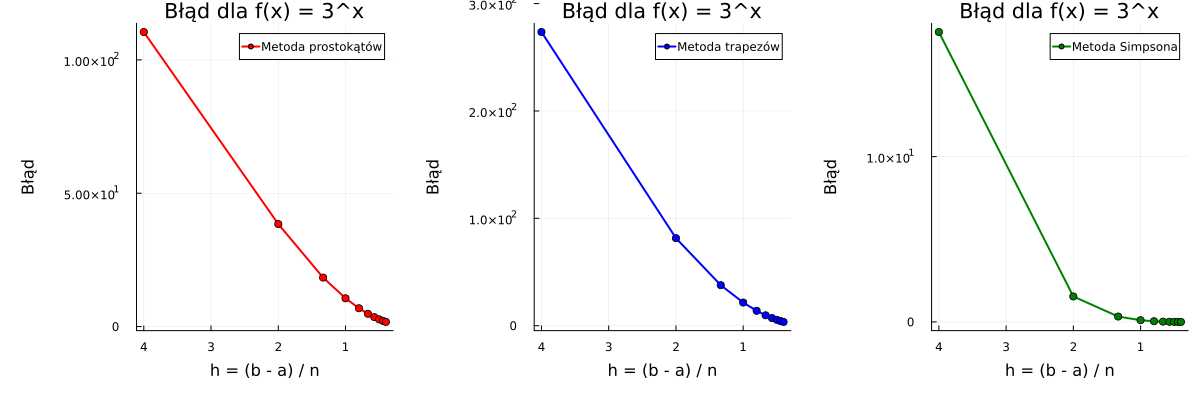

In [127]:
plotErrors(f1, a1, b1, exact1, "f(x) = 3^x")

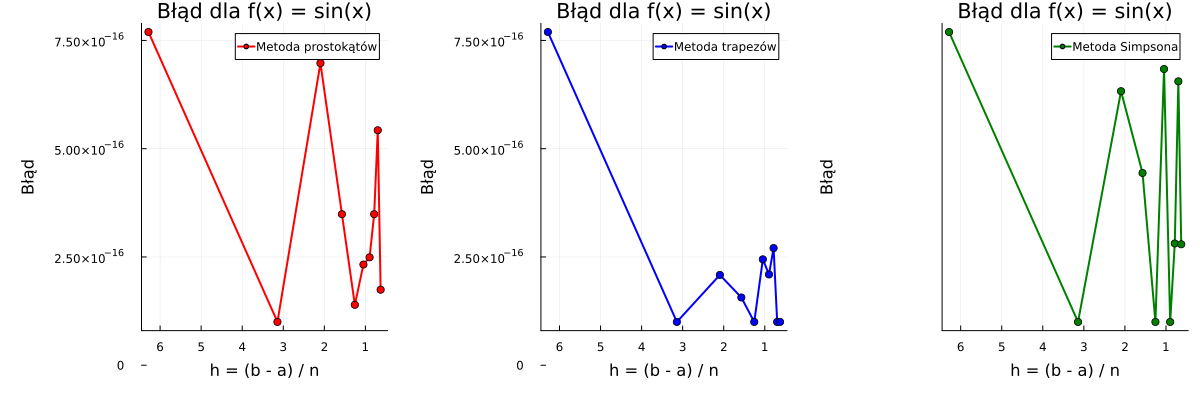

In [128]:
plotErrors(f2, a2, b2, exact2, "f(x) = sin(x)")